In [ ]:
# ── MLOps bootstrap (auto-injected by inject_mlops_cell.py) ──────────────────
import os, warnings, mlflow
warnings.filterwarnings("ignore")

SEED = 42
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED)
except ImportError:
    pass
try:
    import tensorflow as tf; tf.random.set_seed(SEED)
except ImportError:
    pass

_nb_name = os.path.basename(os.path.abspath("__file__") if "__file__" in dir() else ".").replace(".ipynb","")
mlflow.set_tracking_uri("sqlite:///" + str(Path(__file__).parent.parent.parent / "mlflow.db")
                        if "__file__" in dir() else "sqlite:///mlflow.db")
_exp = mlflow.set_experiment(_nb_name or "unnamed_notebook")
print(f"MLflow experiment: {_exp.name}")


# Standard Setup
This cell ensures **reproducibility**, **CUDA detection**, and proper **path management** across all notebooks in this monorepo.

In [ ]:
# ── Standard Setup Cell ──────────────────────────────────────
# Reproducibility | CUDA Detection | Path Management
import os
import random
import logging
from pathlib import Path

import numpy as np

# ── Reproducibility ─────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── PyTorch + CUDA ──────────────────────────────────────────
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"PyTorch {torch.__version__} | Device: {DEVICE}")
    if DEVICE.type == "cuda":
        print(f"  GPU: {torch.cuda.get_device_name(0)}")
except ImportError:
    DEVICE = "cpu"
    print("PyTorch not installed — using CPU")

# ── Paths (relative, portable) ──────────────────────────────
PROJECT_DIR = Path(".").resolve()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project : {PROJECT_DIR.name}")
print(f"Data    : {DATA_DIR}")

# ── Logging ─────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)

# Reinforcement learning for Frozen Lake

Another classical reinforcement learning example with q learning algorithm and frozenlake enviroment. You can check q learning algorithm [here.](https://towardsdatascience.com/simple-reinforcement-learning-q-learning-fcddc4b6fe56)

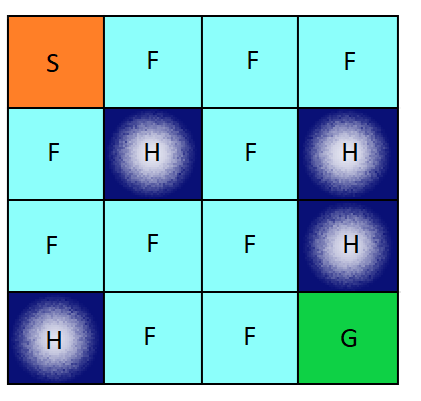

SFFF       (S: starting point, safe)

FHFH       (F: frozen surface, safe)

FFFH       (H: hole, fall to your doom)

HFFG       (G: goal, where the frisbee is located)

In [13]:
import gym
import numpy as np
import random
import matplotlib.pyplot as plt

**Importing enviroment and creating q table**

In [14]:
env = gym.make('FrozenLake-v1')

from gym.envs.registration import register
# To make enviroment deterministic uncomment this area
#register(
#        id='FrozenLakeNotSlippery-v0',
#        entry_point='gym.envs.toy_text:FrozenLakeEnv',
#        kwargs={'map_name' : '4x4', 'is_slippery':False},
#        max_episode_steps = 100,
#        reward_threshold = 0.78)

q_table = np.zeros([env.observation_space.n, env.action_space.n])

**alpha = learning rate**

**gamma = discount factor**

**epsilon = exploration rate**

In [15]:
alpha = 0.1
gamma = 0.9 
epsilon = 0.1
# plotting metric
reward_list = []
dropout_list = []

In [16]:
import json

episode_number = 30000

for i in range(1, episode_number):
    # init environment
    state = env.reset()
    
    reward_count = 0
    dropouts = 0
    
    while True:
        # exploit vs explore to find action epsilon 0.1 => %10 explore %90 exploit
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            state_str = json.dumps(state, sort_keys=True)  # Convert state dictionary to a string
            state_hash = hash(state_str) % q_table.shape[0]  # Convert state string to a hashable value within the index range
            action = np.argmax(q_table[state_hash])
        
        # action process and take reward/ take observation
        step_result = env.step(action)
        next_state = step_result[0]  # Update to match the index of the next state in the step_result
        reward = step_result[1]  # Update to match the index of the reward in the step_result
        done = step_result[2]  # Update to match the index of the done flag in the step_result
        
        # q learning funt
        state_str = json.dumps(state, sort_keys=True)  # Convert state dictionary to a string
        state_hash = hash(state_str) % q_table.shape[0]  # Convert state string to a hashable value within the index range
        
        next_state_str = json.dumps(next_state, sort_keys=True)  # Convert next_state dictionary to a string
        next_state_hash = hash(next_state_str) % q_table.shape[0]  # Convert next_state string to a hashable value within the index range
        
        old_value = q_table[state_hash, action]
        next_max = np.max(q_table[next_state_hash])
        
        next_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
        
        # q table update
        q_table[state_hash, action] = next_value
        
        # update state
        state = next_state
        
        reward_count += reward
    
        if done:
            break
        
    if i % 10 == 0:
        dropout_list.append(dropouts)
        reward_list.append(reward_count)
        print("Episode: {}, reward {}".format(i, reward_count))


Episode: 10, reward 0.0
Episode: 20, reward 0.0
Episode: 30, reward 0.0
Episode: 40, reward 0.0
Episode: 50, reward 0.0
Episode: 60, reward 0.0
Episode: 70, reward 0.0
Episode: 80, reward 0.0
Episode: 90, reward 0.0
Episode: 100, reward 0.0
Episode: 110, reward 0.0
Episode: 120, reward 0.0
Episode: 130, reward 0.0
Episode: 140, reward 0.0
Episode: 150, reward 0.0
Episode: 160, reward 0.0
Episode: 170, reward 0.0
Episode: 180, reward 0.0
Episode: 190, reward 0.0
Episode: 200, reward 0.0
Episode: 210, reward 0.0
Episode: 220, reward 0.0
Episode: 230, reward 0.0
Episode: 240, reward 0.0
Episode: 250, reward 0.0
Episode: 260, reward 0.0
Episode: 270, reward 0.0
Episode: 280, reward 0.0
Episode: 290, reward 0.0
Episode: 300, reward 0.0
Episode: 310, reward 0.0
Episode: 320, reward 0.0
Episode: 330, reward 0.0
Episode: 340, reward 0.0
Episode: 350, reward 0.0
Episode: 360, reward 0.0
Episode: 370, reward 0.0
Episode: 380, reward 0.0
Episode: 390, reward 0.0
Episode: 400, reward 0.0
Episode: 

Episode: 3320, reward 0.0
Episode: 3330, reward 0.0
Episode: 3340, reward 0.0
Episode: 3350, reward 0.0
Episode: 3360, reward 0.0
Episode: 3370, reward 0.0
Episode: 3380, reward 0.0
Episode: 3390, reward 0.0
Episode: 3400, reward 0.0
Episode: 3410, reward 0.0
Episode: 3420, reward 0.0
Episode: 3430, reward 0.0
Episode: 3440, reward 0.0
Episode: 3450, reward 0.0
Episode: 3460, reward 0.0
Episode: 3470, reward 0.0
Episode: 3480, reward 0.0
Episode: 3490, reward 0.0
Episode: 3500, reward 0.0
Episode: 3510, reward 0.0
Episode: 3520, reward 0.0
Episode: 3530, reward 0.0
Episode: 3540, reward 0.0
Episode: 3550, reward 0.0
Episode: 3560, reward 0.0
Episode: 3570, reward 0.0
Episode: 3580, reward 0.0
Episode: 3590, reward 0.0
Episode: 3600, reward 0.0
Episode: 3610, reward 0.0
Episode: 3620, reward 0.0
Episode: 3630, reward 0.0
Episode: 3640, reward 0.0
Episode: 3650, reward 0.0
Episode: 3660, reward 0.0
Episode: 3670, reward 0.0
Episode: 3680, reward 0.0
Episode: 3690, reward 0.0
Episode: 370

Episode: 6550, reward 0.0
Episode: 6560, reward 0.0
Episode: 6570, reward 0.0
Episode: 6580, reward 0.0
Episode: 6590, reward 0.0
Episode: 6600, reward 0.0
Episode: 6610, reward 0.0
Episode: 6620, reward 0.0
Episode: 6630, reward 0.0
Episode: 6640, reward 0.0
Episode: 6650, reward 0.0
Episode: 6660, reward 0.0
Episode: 6670, reward 0.0
Episode: 6680, reward 0.0
Episode: 6690, reward 0.0
Episode: 6700, reward 0.0
Episode: 6710, reward 0.0
Episode: 6720, reward 0.0
Episode: 6730, reward 0.0
Episode: 6740, reward 0.0
Episode: 6750, reward 0.0
Episode: 6760, reward 0.0
Episode: 6770, reward 0.0
Episode: 6780, reward 0.0
Episode: 6790, reward 0.0
Episode: 6800, reward 0.0
Episode: 6810, reward 0.0
Episode: 6820, reward 0.0
Episode: 6830, reward 0.0
Episode: 6840, reward 0.0
Episode: 6850, reward 0.0
Episode: 6860, reward 0.0
Episode: 6870, reward 0.0
Episode: 6880, reward 0.0
Episode: 6890, reward 0.0
Episode: 6900, reward 0.0
Episode: 6910, reward 0.0
Episode: 6920, reward 0.0
Episode: 693

Episode: 9740, reward 0.0
Episode: 9750, reward 0.0
Episode: 9760, reward 0.0
Episode: 9770, reward 0.0
Episode: 9780, reward 0.0
Episode: 9790, reward 0.0
Episode: 9800, reward 0.0
Episode: 9810, reward 0.0
Episode: 9820, reward 0.0
Episode: 9830, reward 0.0
Episode: 9840, reward 0.0
Episode: 9850, reward 0.0
Episode: 9860, reward 0.0
Episode: 9870, reward 0.0
Episode: 9880, reward 0.0
Episode: 9890, reward 0.0
Episode: 9900, reward 0.0
Episode: 9910, reward 0.0
Episode: 9920, reward 0.0
Episode: 9930, reward 0.0
Episode: 9940, reward 0.0
Episode: 9950, reward 0.0
Episode: 9960, reward 0.0
Episode: 9970, reward 0.0
Episode: 9980, reward 0.0
Episode: 9990, reward 0.0
Episode: 10000, reward 0.0
Episode: 10010, reward 0.0
Episode: 10020, reward 0.0
Episode: 10030, reward 0.0
Episode: 10040, reward 0.0
Episode: 10050, reward 0.0
Episode: 10060, reward 0.0
Episode: 10070, reward 0.0
Episode: 10080, reward 0.0
Episode: 10090, reward 0.0
Episode: 10100, reward 0.0
Episode: 10110, reward 0.0


Episode: 12900, reward 0.0
Episode: 12910, reward 0.0
Episode: 12920, reward 0.0
Episode: 12930, reward 0.0
Episode: 12940, reward 0.0
Episode: 12950, reward 0.0
Episode: 12960, reward 0.0
Episode: 12970, reward 0.0
Episode: 12980, reward 0.0
Episode: 12990, reward 0.0
Episode: 13000, reward 0.0
Episode: 13010, reward 0.0
Episode: 13020, reward 0.0
Episode: 13030, reward 0.0
Episode: 13040, reward 0.0
Episode: 13050, reward 0.0
Episode: 13060, reward 0.0
Episode: 13070, reward 0.0
Episode: 13080, reward 0.0
Episode: 13090, reward 0.0
Episode: 13100, reward 0.0
Episode: 13110, reward 0.0
Episode: 13120, reward 0.0
Episode: 13130, reward 0.0
Episode: 13140, reward 0.0
Episode: 13150, reward 0.0
Episode: 13160, reward 0.0
Episode: 13170, reward 0.0
Episode: 13180, reward 0.0
Episode: 13190, reward 0.0
Episode: 13200, reward 0.0
Episode: 13210, reward 0.0
Episode: 13220, reward 0.0
Episode: 13230, reward 0.0
Episode: 13240, reward 0.0
Episode: 13250, reward 0.0
Episode: 13260, reward 0.0
E

Episode: 16030, reward 0.0
Episode: 16040, reward 0.0
Episode: 16050, reward 0.0
Episode: 16060, reward 0.0
Episode: 16070, reward 0.0
Episode: 16080, reward 0.0
Episode: 16090, reward 0.0
Episode: 16100, reward 0.0
Episode: 16110, reward 0.0
Episode: 16120, reward 0.0
Episode: 16130, reward 0.0
Episode: 16140, reward 1.0
Episode: 16150, reward 0.0
Episode: 16160, reward 1.0
Episode: 16170, reward 0.0
Episode: 16180, reward 0.0
Episode: 16190, reward 0.0
Episode: 16200, reward 0.0
Episode: 16210, reward 0.0
Episode: 16220, reward 0.0
Episode: 16230, reward 0.0
Episode: 16240, reward 1.0
Episode: 16250, reward 0.0
Episode: 16260, reward 0.0
Episode: 16270, reward 0.0
Episode: 16280, reward 0.0
Episode: 16290, reward 0.0
Episode: 16300, reward 0.0
Episode: 16310, reward 0.0
Episode: 16320, reward 0.0
Episode: 16330, reward 0.0
Episode: 16340, reward 0.0
Episode: 16350, reward 0.0
Episode: 16360, reward 0.0
Episode: 16370, reward 0.0
Episode: 16380, reward 0.0
Episode: 16390, reward 0.0
E

Episode: 19110, reward 0.0
Episode: 19120, reward 0.0
Episode: 19130, reward 1.0
Episode: 19140, reward 0.0
Episode: 19150, reward 0.0
Episode: 19160, reward 0.0
Episode: 19170, reward 0.0
Episode: 19180, reward 0.0
Episode: 19190, reward 1.0
Episode: 19200, reward 1.0
Episode: 19210, reward 0.0
Episode: 19220, reward 0.0
Episode: 19230, reward 0.0
Episode: 19240, reward 0.0
Episode: 19250, reward 1.0
Episode: 19260, reward 0.0
Episode: 19270, reward 0.0
Episode: 19280, reward 0.0
Episode: 19290, reward 0.0
Episode: 19300, reward 0.0
Episode: 19310, reward 0.0
Episode: 19320, reward 0.0
Episode: 19330, reward 0.0
Episode: 19340, reward 0.0
Episode: 19350, reward 0.0
Episode: 19360, reward 0.0
Episode: 19370, reward 0.0
Episode: 19380, reward 0.0
Episode: 19390, reward 0.0
Episode: 19400, reward 0.0
Episode: 19410, reward 0.0
Episode: 19420, reward 0.0
Episode: 19430, reward 0.0
Episode: 19440, reward 0.0
Episode: 19450, reward 0.0
Episode: 19460, reward 0.0
Episode: 19470, reward 0.0
E

Episode: 22150, reward 0.0
Episode: 22160, reward 0.0
Episode: 22170, reward 0.0
Episode: 22180, reward 0.0
Episode: 22190, reward 1.0
Episode: 22200, reward 0.0
Episode: 22210, reward 0.0
Episode: 22220, reward 0.0
Episode: 22230, reward 0.0
Episode: 22240, reward 0.0
Episode: 22250, reward 0.0
Episode: 22260, reward 1.0
Episode: 22270, reward 0.0
Episode: 22280, reward 0.0
Episode: 22290, reward 0.0
Episode: 22300, reward 0.0
Episode: 22310, reward 0.0
Episode: 22320, reward 0.0
Episode: 22330, reward 0.0
Episode: 22340, reward 0.0
Episode: 22350, reward 0.0
Episode: 22360, reward 0.0
Episode: 22370, reward 0.0
Episode: 22380, reward 0.0
Episode: 22390, reward 0.0
Episode: 22400, reward 1.0
Episode: 22410, reward 0.0
Episode: 22420, reward 1.0
Episode: 22430, reward 0.0
Episode: 22440, reward 1.0
Episode: 22450, reward 0.0
Episode: 22460, reward 0.0
Episode: 22470, reward 0.0
Episode: 22480, reward 1.0
Episode: 22490, reward 0.0
Episode: 22500, reward 0.0
Episode: 22510, reward 0.0
E

Episode: 25210, reward 0.0
Episode: 25220, reward 0.0
Episode: 25230, reward 0.0
Episode: 25240, reward 1.0
Episode: 25250, reward 0.0
Episode: 25260, reward 1.0
Episode: 25270, reward 0.0
Episode: 25280, reward 0.0
Episode: 25290, reward 1.0
Episode: 25300, reward 1.0
Episode: 25310, reward 0.0
Episode: 25320, reward 1.0
Episode: 25330, reward 0.0
Episode: 25340, reward 0.0
Episode: 25350, reward 1.0
Episode: 25360, reward 0.0
Episode: 25370, reward 0.0
Episode: 25380, reward 0.0
Episode: 25390, reward 0.0
Episode: 25400, reward 0.0
Episode: 25410, reward 0.0
Episode: 25420, reward 0.0
Episode: 25430, reward 0.0
Episode: 25440, reward 1.0
Episode: 25450, reward 0.0
Episode: 25460, reward 0.0
Episode: 25470, reward 0.0
Episode: 25480, reward 0.0
Episode: 25490, reward 0.0
Episode: 25500, reward 1.0
Episode: 25510, reward 0.0
Episode: 25520, reward 0.0
Episode: 25530, reward 0.0
Episode: 25540, reward 0.0
Episode: 25550, reward 0.0
Episode: 25560, reward 0.0
Episode: 25570, reward 0.0
E

Episode: 28390, reward 0.0
Episode: 28400, reward 0.0
Episode: 28410, reward 0.0
Episode: 28420, reward 0.0
Episode: 28430, reward 0.0
Episode: 28440, reward 0.0
Episode: 28450, reward 0.0
Episode: 28460, reward 0.0
Episode: 28470, reward 0.0
Episode: 28480, reward 0.0
Episode: 28490, reward 1.0
Episode: 28500, reward 0.0
Episode: 28510, reward 0.0
Episode: 28520, reward 0.0
Episode: 28530, reward 0.0
Episode: 28540, reward 0.0
Episode: 28550, reward 0.0
Episode: 28560, reward 0.0
Episode: 28570, reward 0.0
Episode: 28580, reward 1.0
Episode: 28590, reward 0.0
Episode: 28600, reward 0.0
Episode: 28610, reward 0.0
Episode: 28620, reward 0.0
Episode: 28630, reward 0.0
Episode: 28640, reward 0.0
Episode: 28650, reward 0.0
Episode: 28660, reward 0.0
Episode: 28670, reward 0.0
Episode: 28680, reward 1.0
Episode: 28690, reward 1.0
Episode: 28700, reward 0.0
Episode: 28710, reward 0.0
Episode: 28720, reward 0.0
Episode: 28730, reward 0.0
Episode: 28740, reward 0.0
Episode: 28750, reward 0.0
E

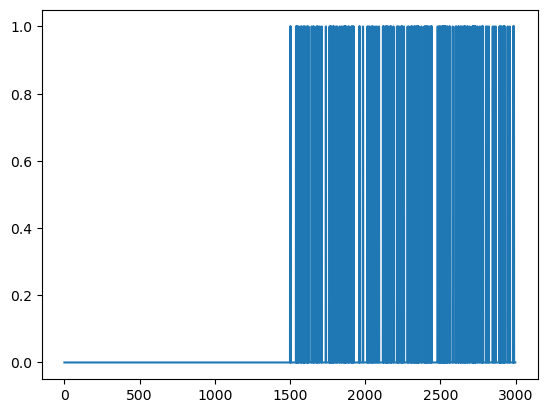

In [17]:
plt.plot(reward_list)